# Day 3: Machine Learning from Data to Evaluation

We will build a binary classifier for Titanic survival. The notebook uses pandas, NumPy, and Matplotlib so every modeling step remains visible. Run all cells from a fresh kernel.

## 1. Frame the problem and validate the data source

The target `survived` is binary: 1 means survived and 0 means did not survive. Loading the public CSV URL requires an Internet connection, and the remote source may change. The explicit row and schema assertions below make such a change visible instead of silently changing the lesson.

In [1]:
import ssl
from pathlib import Path
from urllib.error import URLError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
fallback_candidates = [Path("../datasets/titanic.csv"), Path("datasets/titanic.csv")]
try:
    titanic = pd.read_csv(TITANIC_URL)
    data_source = TITANIC_URL
except (URLError, ssl.SSLError, OSError) as network_error:
    fallback_path = next((path for path in fallback_candidates if path.exists()), None)
    if fallback_path is None:
        raise FileNotFoundError("Titanic download failed and no local fallback was found.") from network_error
    titanic = pd.read_csv(fallback_path)
    data_source = str(fallback_path.resolve())

print(f"Data source: {data_source}")
titanic.columns = titanic.columns.str.lower()
expected_columns = [
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked", "class", "who", "adult_male", "deck", "embark_town",
    "alive", "alone",
]
if titanic.shape != (891, 15):
    raise ValueError(f"Unexpected Titanic shape: {titanic.shape}")
if titanic.columns.tolist() != expected_columns:
    raise ValueError(f"Unexpected Titanic columns: {titanic.columns.tolist()}")
print(f"Rows: {titanic.shape[0]:,}; columns: {titanic.shape[1]}")
titanic.head()

Data source: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv
Rows: 891; columns: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Fix the modeling choices before evaluation

We choose six raw features before looking at validation or test performance. `sex` becomes a binary indicator. Passenger class is categorical, so we use two one-hot indicators—`pclass_2` and `pclass_3`—with first class as the reference. This avoids imposing an equal linear step from class 1 to 2 and from 2 to 3.

In [2]:
raw_feature_names = ["pclass", "sex", "age", "sibsp", "parch", "fare"]
feature_names = ["sex", "age", "sibsp", "parch", "fare", "pclass_2", "pclass_3"]
continuous_features = ["age", "sibsp", "parch", "fare"]
model_data = titanic[raw_feature_names + ["survived"]].copy()
model_data["sex"] = model_data["sex"].map({"male": 0, "female": 1})
print(model_data.isna().sum())
model_data.head()

pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
survived      0
dtype: int64


,pclass,sex,age,sibsp,parch,fare,survived
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,1
3,1,1,35.0,1,0,53.1000,1
4,3,0,35.0,0,0,8.0500,0


## 3. Make stratified train, validation, and test sets

The 60/20/20 split is stratified so each outcome contributes rows to every subset. Training estimates model weights. Validation is the only subset allowed to guide threshold, feature, or model choices. The test labels stay unused until the final evaluation.

In [3]:
def stratified_three_way_split(target, train_fraction=0.6, validation_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_parts, validation_parts, test_parts = [], [], []
    for label in np.unique(target):
        label_indices = np.flatnonzero(target == label)
        rng.shuffle(label_indices)
        train_end = int(train_fraction * len(label_indices))
        validation_end = train_end + int(validation_fraction * len(label_indices))
        train_parts.append(label_indices[:train_end])
        validation_parts.append(label_indices[train_end:validation_end])
        test_parts.append(label_indices[validation_end:])
    splits = [np.concatenate(parts) for parts in (train_parts, validation_parts, test_parts)]
    for split in splits:
        rng.shuffle(split)
    return tuple(splits)

target_values = model_data["survived"].to_numpy(dtype=int)
train_indices, validation_indices, test_indices = stratified_three_way_split(target_values)
assert len(set(train_indices) & set(validation_indices)) == 0
assert len(set(train_indices) & set(test_indices)) == 0
assert len(set(validation_indices) & set(test_indices)) == 0
assert len(train_indices) + len(validation_indices) + len(test_indices) == len(model_data)
train_data = model_data.iloc[train_indices].copy()
validation_data = model_data.iloc[validation_indices].copy()
test_data = model_data.iloc[test_indices].copy()
print(f"train={len(train_data)}, validation={len(validation_data)}, test={len(test_data)}")

train=534, validation=177, test=180


## 4. Fit preprocessing on the training set

Age and fare medians come only from training rows. The explicit one-hot encoding uses first class as the reference. The same learned medians are then applied to validation and test rows.

In [4]:
fill_values = train_data[["age", "fare"]].median()

def prepare_features(data, training_fill_values):
    prepared = data[raw_feature_names].copy()
    prepared[["age", "fare"]] = prepared[["age", "fare"]].fillna(training_fill_values)
    prepared["pclass_2"] = (prepared["pclass"] == 2).astype(float)
    prepared["pclass_3"] = (prepared["pclass"] == 3).astype(float)
    prepared = prepared.drop(columns="pclass")
    return prepared[feature_names]

train_features = prepare_features(train_data, fill_values)
validation_features = prepare_features(validation_data, fill_values)
test_features = prepare_features(test_data, fill_values)
assert not train_features.isna().any().any()
assert not validation_features.isna().any().any()
assert not test_features.isna().any().any()
train_features.head()

,sex,age,sibsp,parch,fare,pclass_2,pclass_3
308,0,30.0,1,0,24.0000,1.0,0.0
424,0,18.0,1,1,20.2125,0.0,1.0
524,0,28.0,0,0,7.2292,0.0,1.0
307,1,17.0,1,0,108.9000,0.0,0.0
810,0,26.0,0,0,7.8875,0.0,1.0


Standardization puts continuous features on comparable scales. Means and standard deviations again come only from training rows; binary indicators remain 0/1.

In [5]:
continuous_mean = train_features[continuous_features].mean()
continuous_std = train_features[continuous_features].std(ddof=0).replace(0, 1.0)

def standardize_features(features):
    standardized = features.copy()
    standardized[continuous_features] = (standardized[continuous_features] - continuous_mean) / continuous_std
    return standardized

train_features = standardize_features(train_features)
validation_features = standardize_features(validation_features)
test_features = standardize_features(test_features)
X_train = train_features.to_numpy(dtype=float)
X_validation = validation_features.to_numpy(dtype=float)
X_test = test_features.to_numpy(dtype=float)
y_train = train_data["survived"].to_numpy(dtype=float)
y_validation = validation_data["survived"].to_numpy(dtype=float)
y_test = test_data["survived"].to_numpy(dtype=float)
assert np.allclose(train_features[continuous_features].mean(), 0.0, atol=1e-10)
train_features.describe().loc[["mean", "std"]].round(3)

,sex,age,sibsp,parch,fare,pclass_2,pclass_3
mean,0.369,-0.000,0.000,-0.000,0.000,0.210,0.549
std,0.483,1.001,1.001,1.001,1.001,0.408,0.498


## 5. Train logistic regression

Logistic regression converts a weighted sum into a probability with the sigmoid function. Gradient descent adjusts weights to reduce binary cross-entropy. The learning rate and iteration count are fixed before validation.

In [6]:
def sigmoid(values):
    clipped = np.clip(values, -500, 500)
    return 1.0 / (1.0 + np.exp(-clipped))

def binary_cross_entropy(actual, probability):
    safe_probability = np.clip(probability, 1e-12, 1 - 1e-12)
    return -np.mean(actual * np.log(safe_probability) + (1 - actual) * np.log(1 - safe_probability))

assert np.isclose(sigmoid(np.array([0.0]))[0], 0.5)
assert binary_cross_entropy(np.array([1.0]), np.array([0.9])) < binary_cross_entropy(np.array([1.0]), np.array([0.6]))

In [7]:
weights = np.zeros(X_train.shape[1])
bias = 0.0
learning_rate = 0.1
loss_history = []

for step in range(2000):
    train_probability = sigmoid(X_train @ weights + bias)
    error = train_probability - y_train
    weights = weights - learning_rate * (X_train.T @ error) / len(y_train)
    bias = bias - learning_rate * error.mean()
    if step % 100 == 0:
        loss_history.append(binary_cross_entropy(y_train, train_probability))

final_train_probability = sigmoid(X_train @ weights + bias)
final_loss = binary_cross_entropy(y_train, final_train_probability)
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss from final weights: {final_loss:.4f}")
assert final_loss < loss_history[0]

Initial loss: 0.6931
Final loss from final weights: 0.4215


## 6. Tune the decision threshold on validation data only

Accuracy alone can hide class-specific mistakes. Precision, recall, and F1 use safe division so a threshold with no predicted or actual positives produces a defined score of 0 instead of a crash. We select the threshold with validation F1; the test set remains untouched.

In [8]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0

def binary_metrics(actual, probability, threshold):
    predicted = (probability >= threshold).astype(int)
    true_negative = int(np.sum((actual == 0) & (predicted == 0)))
    false_positive = int(np.sum((actual == 0) & (predicted == 1)))
    false_negative = int(np.sum((actual == 1) & (predicted == 0)))
    true_positive = int(np.sum((actual == 1) & (predicted == 1)))
    precision = safe_divide(true_positive, true_positive + false_positive)
    recall = safe_divide(true_positive, true_positive + false_negative)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    return {
        "accuracy": float(np.mean(predicted == actual)),
        "precision": precision, "recall": recall, "f1": f1,
        "tn": true_negative, "fp": false_positive,
        "fn": false_negative, "tp": true_positive,
    }

assert safe_divide(3, 0) == 0.0
assert safe_divide(3, 4) == 0.75

In [9]:
validation_probability = sigmoid(X_validation @ weights + bias)
candidate_thresholds = np.arange(0.30, 0.71, 0.05)
validation_results = pd.DataFrame([
    {"threshold": threshold, **binary_metrics(y_validation, validation_probability, threshold)}
    for threshold in candidate_thresholds
])
best_row = validation_results.loc[validation_results["f1"].idxmax()]
best_threshold = float(best_row["threshold"])
print(f"Selected threshold from validation F1: {best_threshold:.2f}")
validation_results[["threshold", "accuracy", "precision", "recall", "f1"]].round(3)

Selected threshold from validation F1: 0.45


,threshold,accuracy,precision,recall,f1
0,0.30,0.734,0.648,0.676,0.662
1,0.35,0.740,0.657,0.676,0.667
2,0.40,0.757,0.687,0.676,0.681
3,0.45,0.774,0.726,0.662,0.692
4,0.50,0.768,0.729,0.632,0.677
5,0.55,0.768,0.737,0.618,0.672
6,0.60,0.785,0.778,0.618,0.689
7,0.65,0.797,0.881,0.544,0.673
8,0.70,0.797,0.921,0.515,0.660


## 7. Interpret the fitted model before opening the test set

Each coefficient is a conditional log-odds association: it describes the change in predicted survival log-odds while holding the other included features constant. Continuous-feature coefficients correspond to a one-training-standard-deviation increase; `sex` compares female with male, and the class indicators compare second or third class with first class. These are associations, not causal effects.

In [10]:
coefficient_table = (
    pd.DataFrame({"feature": feature_names, "conditional_log_odds_coefficient": weights})
    .assign(absolute_coefficient=lambda table: table["conditional_log_odds_coefficient"].abs())
    .sort_values("absolute_coefficient", ascending=False)
)
coefficient_table.round(3)

,feature,conditional_log_odds_coefficient,absolute_coefficient
0,sex,2.919,2.919
6,pclass_3,-1.841,1.841
5,pclass_2,-0.533,0.533
1,age,-0.458,0.458
4,fare,0.277,0.277
2,sibsp,-0.229,0.229
3,parch,-0.207,0.207


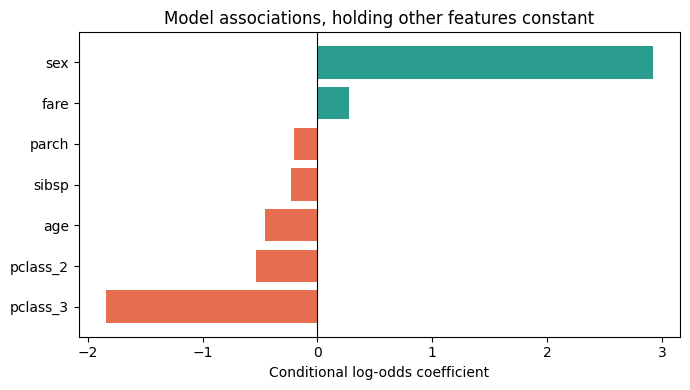

In [11]:
plot_table = coefficient_table.sort_values("conditional_log_odds_coefficient")
colors = np.where(plot_table["conditional_log_odds_coefficient"] >= 0, "#2a9d8f", "#e76f51")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_table["feature"], plot_table["conditional_log_odds_coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="Conditional log-odds coefficient", title="Model associations, holding other features constant")
plt.tight_layout()
plt.show()

## 8. Final one-time test evaluation

Only now do we use the test labels. This estimate answers how the already-fixed preprocessing, model, and validation-selected threshold perform on unseen data. Do not revise the pipeline in response to this result.

Final test metrics:
accuracy     0.767
precision    0.729
recall       0.623
f1           0.672
dtype: float64
          predicted 0  predicted 1
actual 0           95           16
actual 1           26           43


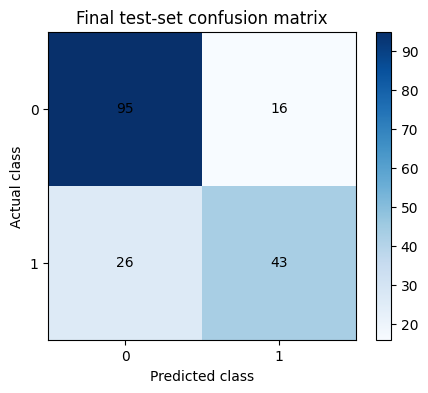

In [12]:
test_probability = sigmoid(X_test @ weights + bias)
test_metrics = binary_metrics(y_test, test_probability, best_threshold)
print("Final test metrics:")
print(pd.Series({name: test_metrics[name] for name in ["accuracy", "precision", "recall", "f1"]}).round(3))
confusion = np.array([[test_metrics["tn"], test_metrics["fp"]], [test_metrics["fn"], test_metrics["tp"]]])
print(pd.DataFrame(confusion, index=["actual 0", "actual 1"], columns=["predicted 0", "predicted 1"]))

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion, cmap="Blues")
for row in range(2):
    for column in range(2):
        ax.text(column, row, confusion[row, column], ha="center", va="center")
ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predicted class", ylabel="Actual class", title="Final test-set confusion matrix")
fig.colorbar(image, ax=ax)
plt.show()